# GP-PHS: Driven Duffing Oscillator, Chaotic Regime Stress Test

### A 2-State Port-Hamiltonian System with a Quartic Double-Well Potential, Driven into Sensitive Dependence

The Hamiltonian of the system is

$$
H(q,p) = \frac{p^2}{2} + \frac{1}{4}q^4 - \frac{1}{2}q^2
$$

- $q$ is position, $p$ is momentum,
- the potential $\frac{1}{4}q^4 - \frac{1}{2}q^2$ has two symmetric minima at $q=\pm1$, the classic Duffing double well.

## Mathematical Formulation

### Interconnection Matrix (Constant)
$$
J = \begin{bmatrix}0 & 1 \\ -1 & 0\end{bmatrix}
$$

### Dissipation Matrix (Constant & PSD)
$$
R = \operatorname{diag}(0,\ b)
$$

**Parameter**: $b \geq 0$ (damping, unknown)

### Input Matrix (Constant)
$$
G = \begin{bmatrix}0 \\ 1\end{bmatrix}
$$

### Complete Dynamics
$$
\dot{x} = (J-R)\nabla H(x) + Gu
$$

Explicitly, with $\nabla H = (q^3-q,\ p)$:
$$
\dot q = p, \qquad \dot p = q - q^3 - bp + u(t)
$$
This is the standard forced, damped Duffing equation. The forcing $u(t) = \gamma\cos(\omega t)$ is fixed at $\gamma=0.5,\ \omega=1.2$ -- a parameter combination documented in the nonlinear-dynamics literature to produce chaotic trajectories for this damping level.

### Parameters to Learn
$$
\theta = \{b\} \quad \text{(1 parameter -- deliberately minimal, since the } H \text{ shape and rollout behavior under chaos are the things under test, not multi-parameter recovery)}
$$

### Install (Colab only)
Skip this step when running locally.

In [1]:
# ── Google Colab / fresh environment setup ──────────────────────────────────
# !pip install -q git+https://github.com/essey1/neuromancer.git gpytorch scipy

## Imports

In [2]:
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parents[1] / "src"))

import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
import gpytorch
from scipy.integrate import odeint
from torch.utils.data import DataLoader

from neuromancer import psl
from neuromancer import dataset
from neuromancer.psl import plot
from neuromancer.dynamics import gp_phs, ode
from neuromancer.psl import gp_smoother
from neuromancer.modules import hamiltonian_approximator
from neuromancer.system import Node, System
from neuromancer.dataset import DictDataset
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.loss import AugmentedLagrangeLoss
from neuromancer.problem import Problem
from neuromancer.trainer import Trainer
from neuromancer.loggers import BasicLogger

torch.manual_seed(0); np.random.seed(0)

## Configuration

In [3]:
# ============================================================
# DATA & TRAINING HYPERPARAMETERS
# ============================================================
N_POINTS = 300
NOISE    = 0.01
N_EPOCHS = 5000
NX, NU   = 2, 1
T_SIM    = 10.0

X0_TRAIN = [
    [0.5,  0.0],
    [-0.5, 0.0],
    [1.0,  0.2],
    [-1.0, -0.2],
    [0.2,  0.5],
]
X0_TEST = [
    [0.5,    0.0],       # baseline
    [0.5001, 0.0],       # perturbed by 1e-4 -- same IC family, tests sensitive dependence directly
    [-0.3,   0.3],
]

# ============================================================
# TRUE SYSTEM PARAMETERS
# ============================================================
B_TRUE = 0.2      # damping

# Input signal parameters (fixed chaotic-regime forcing)
INPUT_AMP  = 0.5      # amplitude gamma
INPUT_FREQ = 1.2      # frequency omega

## True System

### Define true dynamics

In [4]:
# Define true system parameters
true_params = {
    'b': B_TRUE
}

def H_true(q, p):
    """Hamiltonian energy -- quartic double-well potential"""
    return 0.5*p**2 + 0.25*q**4 - 0.5*q**2

def grad_H_true(state):
    """Gradient of Hamiltonian"""
    q, p = state
    return np.array([q**3 - q, p])

def J_true(state):
    """Skew-symmetric interconnection matrix J (constant)"""
    return np.array([
        [0,  1],
        [-1, 0]
    ])

def R_true(state):
    """Dissipation matrix R [diagonal, constant]"""
    return np.diag([0.0, B_TRUE])

def G_mat_true(state):
    """Input matrix G (constant)"""
    return np.array([
        [0.0],
        [1.0]
    ])

def input_signal(t):
    """Time-dependent input signal u(t) -- fixed chaotic-regime forcing"""
    u1 = INPUT_AMP * np.cos(INPUT_FREQ * t)
    return np.array([u1])

def dynamics(state, t, sig=input_signal):
    """Complete PHS dynamics: xdot = (J-R) grad_H + Gu"""
    grad_h = grad_H_true(state)
    J = J_true(state)
    R = R_true(state)
    G = G_mat_true(state)
    u = sig(t)
    return (J - R) @ grad_h + G @ u

### Plot true trajectory

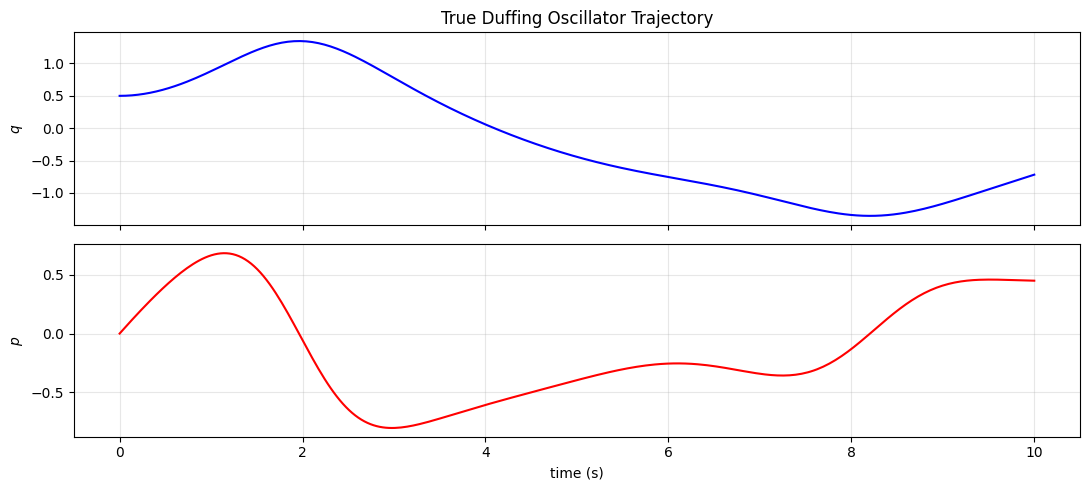

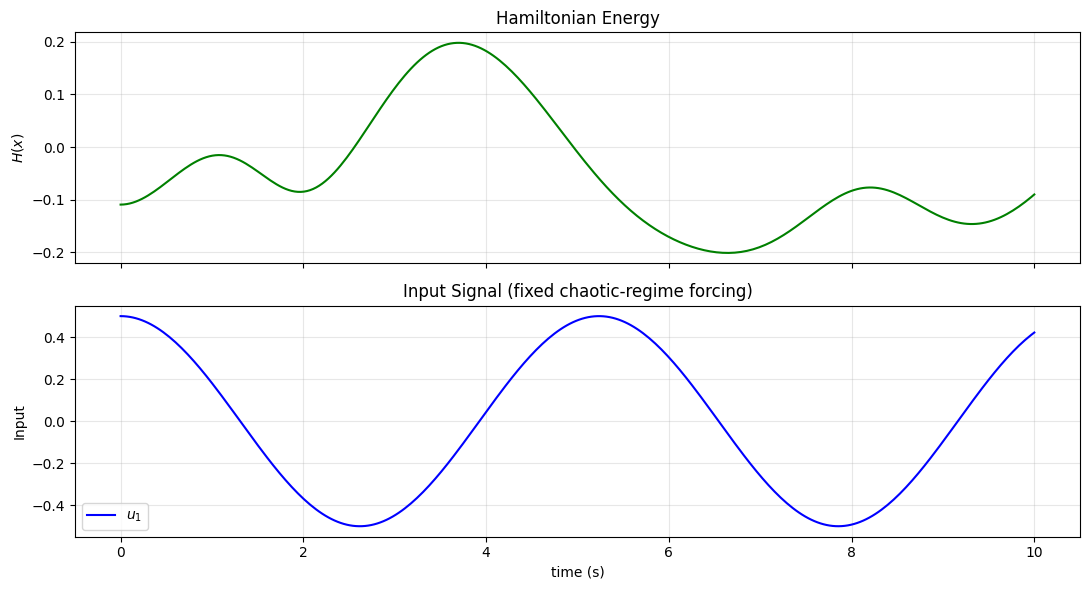

In [5]:
# Plot a representative trajectory
x0  = X0_TRAIN[0]
t_i = np.linspace(0, T_SIM, N_POINTS)
traj_i = odeint(lambda state, t, s=input_signal: dynamics(state, t, s), x0, t_i)
u_i    = np.array([input_signal(t) for t in t_i])
H_i    = np.array([H_true(x[0], x[1]) for x in traj_i])

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
labels = [r'$q$', r'$p$']
colors = ['b', 'r']
for j, (ax, lbl, col) in enumerate(zip(axes, labels, colors)):
    ax.plot(t_i, traj_i[:, j], col, lw=1.5)
    ax.set_ylabel(lbl); ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('time (s)')
axes[0].set_title('True Duffing Oscillator Trajectory')
plt.tight_layout(); plt.show()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax1.plot(t_i, H_i, 'g', lw=1.5)
ax1.set_ylabel(r'$H(x)$'); ax1.grid(True, alpha=0.3)
ax1.set_title('Hamiltonian Energy')
ax2.plot(t_i, u_i[:, 0], 'b', label=r'$u_1$', lw=1.5)
ax2.set_ylabel('Input'); ax2.set_xlabel('time (s)'); ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_title('Input Signal (fixed chaotic-regime forcing)')
plt.tight_layout(); plt.show()

## Step 1: Dataset Preparation

### Data Sampling & Dataset Preparation



In [6]:
# DATA GENERATION
sigs = [input_signal] * len(X0_TRAIN)
trajs_true, trajs, us, t_all = [], [], [], []
for i, (x0, sig) in enumerate(zip(X0_TRAIN, sigs)):
    t_i = np.linspace(i * T_SIM, (i + 1) * T_SIM, N_POINTS)
    x_i = odeint(lambda state, t, s=sig: dynamics(state, t, s), x0, t_i)
    u_i = np.array([sig(t) for t in t_i])
    trajs_true.append(x_i)
    x_noisy_i = x_i + np.random.normal(0, NOISE, x_i.shape)
    trajs.append(x_noisy_i); us.append(u_i); t_all.append(t_i)

# GP SMOOTHER
smoothed, xdots, xdot_vars = [], [], []
for t_i, x_i in zip(t_all, trajs):
    x_s, xd, xdv = gp_smoother.gp_smooth(t_i, x_i)
    smoothed.append(x_s); xdots.append(xd); xdot_vars.append(xdv)

# DATA LOADERS
train_loader, dev_loader, test_loader = dataset.get_gpphs_dataloaders(
    x=np.concatenate(smoothed),
    x_dot=np.concatenate(xdots),
    u=np.concatenate(us),
    x_dot_var=np.concatenate(xdot_vars),
    split_ratio=[75.0, 15.0, 10.0],
    batch_size=len(X0_TRAIN) * N_POINTS,
)

C:\Users\arayae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\_compile.py:54: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)
C:\Users\arayae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gpytorch\models\exact_gp.py:299: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


### Plot

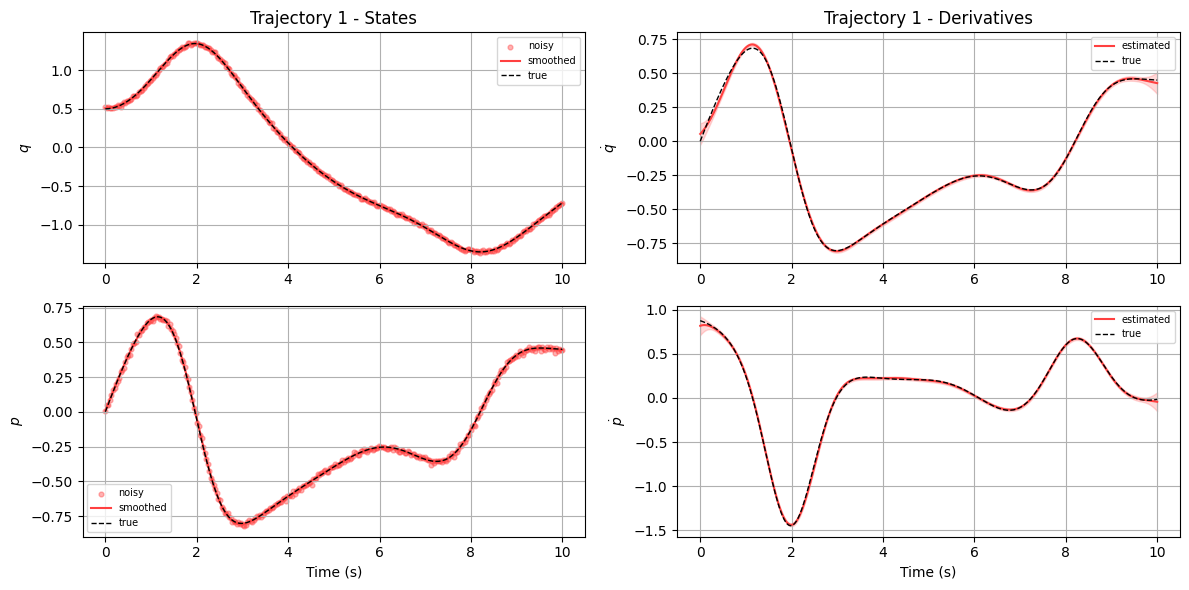

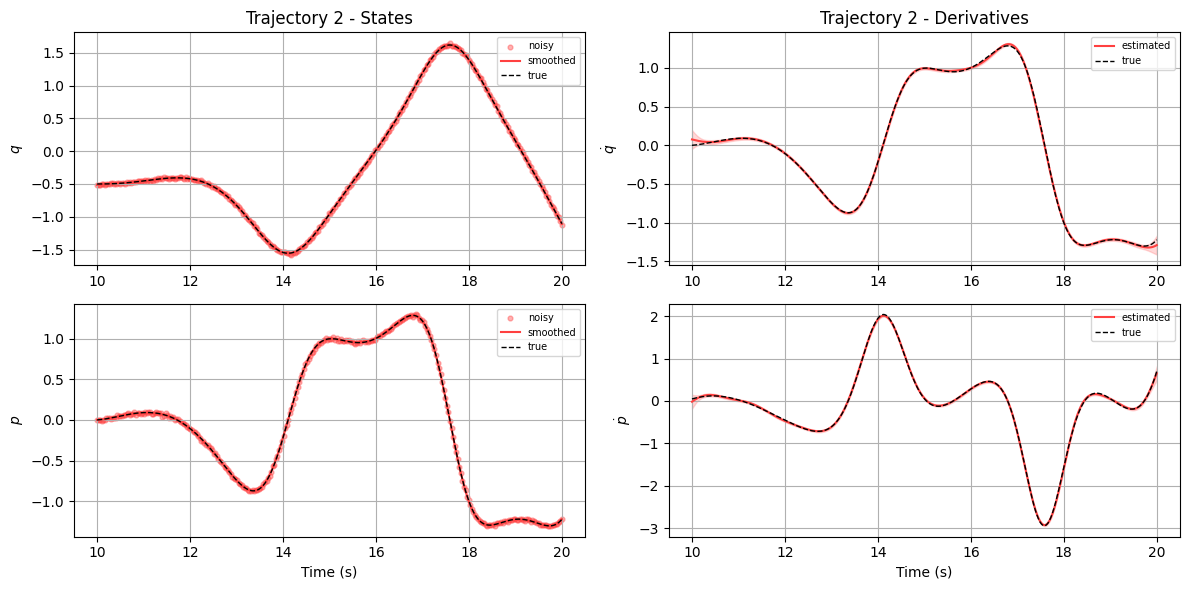

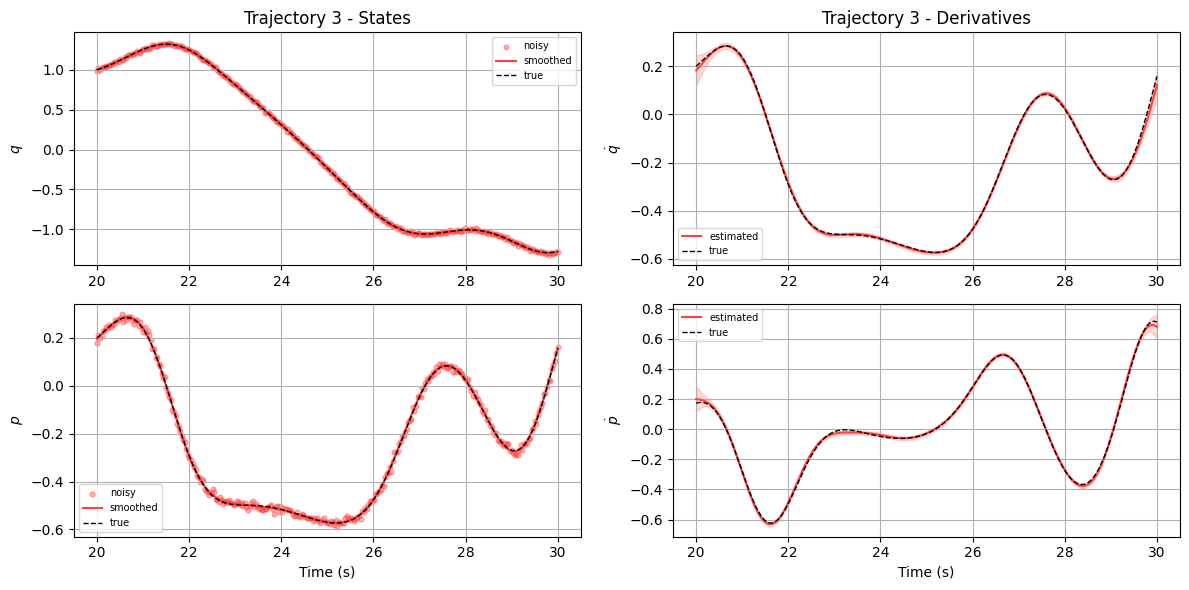

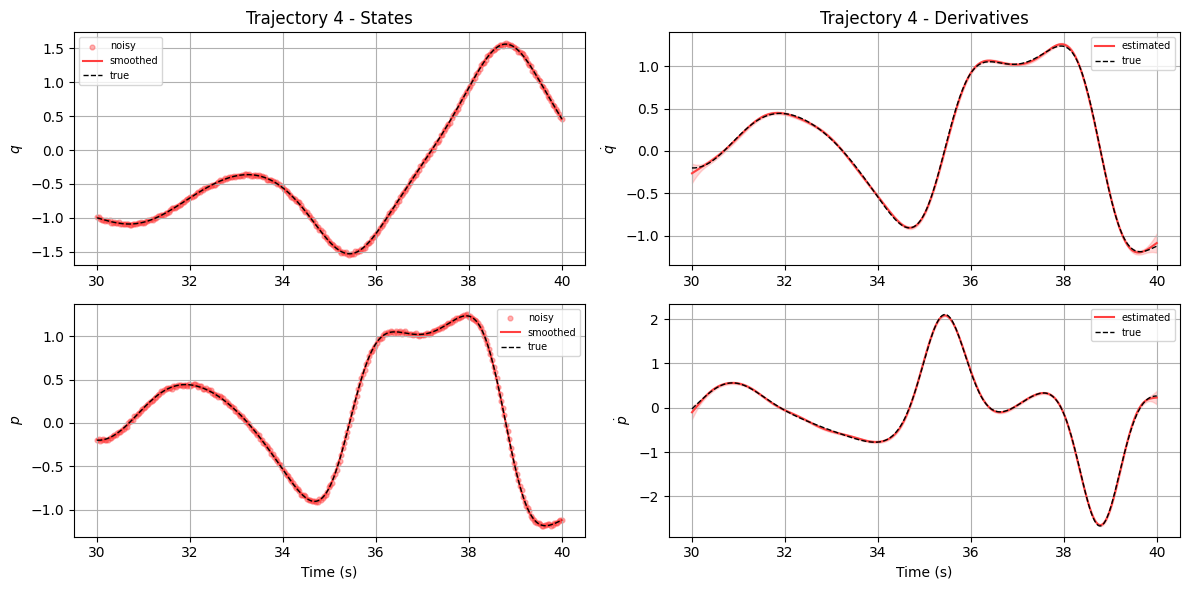

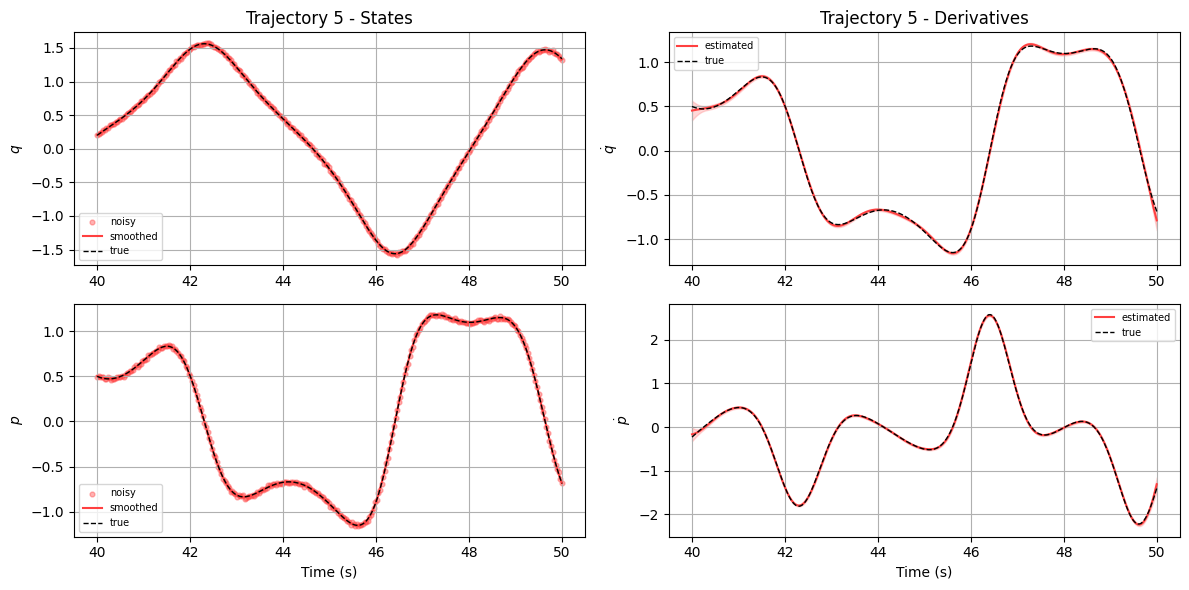

In [7]:
plot.pltGPSmooth(
    t_all,
    trajs,
    smoothed,
    xdots,
    xdot_vars,
    x_trues=trajs_true,
    dynamics=dynamics,
    sigs=sigs,
    state_lbls=[r'$q$', r'$p$'],
    deriv_lbls=[r'$\dot{q}$', r'$\dot{p}$'],
)

## Step 2: PHS Structure

Define 1 learnable damping parameter.

In [8]:
# Raw tensor promoted to nn.Parameter by variable()
b = variable(torch.tensor([0.5], requires_grad=True), display_name='b')

### Construct PHSMatrices

In [9]:
phs = gp_phs.PHSMatrices(
    nx=NX, nu=NU,
    J_upper={
        (0, 1): lambda x: torch.ones(x.shape[0])
    },
    R_diag={
        0: lambda x: torch.zeros(x.shape[0]),
        1: lambda x: b.value * torch.ones(x.shape[0])
    },
    G_full={
        (1, 0): lambda x: torch.ones(x.shape[0])
    }
)

## Step 3: Build Node, Loss, and Problem

In [10]:
# Build node
gpphs_module = gp_phs.GPPHSNode(phs, NX, NU)
gpphs_node = Node(gpphs_module, ['X', 'U', 'Xdot', 'Xdot_var'], ['nlml'], name='gp_phs')

# Objective
nlml = variable('nlml')
nlml_loss = nlml.minimize()
nlml_loss.name = 'nlml_loss'

# Aggregate and build problem
objectives  = [nlml_loss]
constraints = []

loss    = PenaltyLoss(objectives, constraints)
problem = Problem([gpphs_node], loss)

## Step 4: Training

In [11]:
optimizer = torch.optim.Adam(problem.parameters(), lr=0.0003)
logger    = BasicLogger(args=None, savedir='test', verbosity=1,
                        stdout=['train_loss', 'dev_loss'])
trainer   = Trainer(
    problem,
    train_loader,
    dev_loader,
    optimizer,
    epochs=N_EPOCHS,
    patience=N_EPOCHS,
    epoch_verbose=5,
    train_metric='train_loss',
    dev_metric='dev_loss',
    eval_metric='dev_loss',
    logger=logger,
)

None
Number of parameters: 5


In [12]:
# train
best_model = trainer.train()
problem.load_state_dict(best_model)

epoch: 0	train_loss: 173213.25000	dev_loss: -532.49487	eltime:  0.49566
epoch: 1	train_loss: 169293.25000	dev_loss: -576.25244	eltime:  0.93426
epoch: 2	train_loss: 165031.87500	dev_loss: -617.57690	eltime:  1.44661
epoch: 3	train_loss: 159296.87500	dev_loss: -655.42981	eltime:  1.91894
epoch: 4	train_loss: 153822.42188	dev_loss: -691.06604	eltime:  2.40065
epoch: 5	train_loss: 148943.96875	dev_loss: -724.11548	eltime:  2.81796
epoch: 6	train_loss: 146144.01562	dev_loss: -755.05127	eltime:  3.23592
epoch: 7	train_loss: 140857.51562	dev_loss: -783.80115	eltime:  3.67702
epoch: 8	train_loss: 136644.98438	dev_loss: -810.35767	eltime:  4.13188
epoch: 9	train_loss: 132586.92188	dev_loss: -835.14368	eltime:  4.58433
epoch: 10	train_loss: 128747.46875	dev_loss: -858.42725	eltime:  5.10371
epoch: 11	train_loss: 125519.80469	dev_loss: -879.83301	eltime:  5.59151
epoch: 12	train_loss: 120507.28906	dev_loss: -899.85181	eltime:  6.04656
epoch: 13	train_loss: 117343.64844	dev_loss: -918.50012	eltim

<All keys matched successfully>

### Parameter Recovery

In [13]:
gp_phs.param_table({
    'b': (b, B_TRUE),
})

Parameter  True  Learned  Rel. Error %
        b   0.2 0.200249       0.12453

Mean relative error:   0.12%
Median relative error: 0.12%


,Parameter,True,Learned,Rel. Error %
0,b,0.2,0.200249,0.12453


## Step 5: Hamiltonian Posterior

$H$ is identifiable up to an additive constant; the posterior mean is aligned to the true $H$ at training points.

### Compute posterior

In [14]:
# BUILD GP POSTERIOR
posterior = gpphs_node.callable.posterior()

# COMPUTE HAMILTONIAN POSTERIOR -- all trajectories
H_mean, H_var, H_samples = posterior.predict(
    smoothed,
    us,
    xdots,
    xdot_vars,
    n_samples=50,
)

# Concatenate all trajectories for evaluation
x_all      = np.concatenate(smoothed, axis=0)
u_all      = np.concatenate(us, axis=0)
xdot_true  = np.concatenate(xdots, axis=0)
x_all_t    = torch.tensor(x_all, dtype=torch.float32)

# TRUE HAMILTONIAN -- all trajectories
H_true_all = np.array([H_true(x[0], x[1]) for x in x_all])

### Plot Hamiltonian posterior

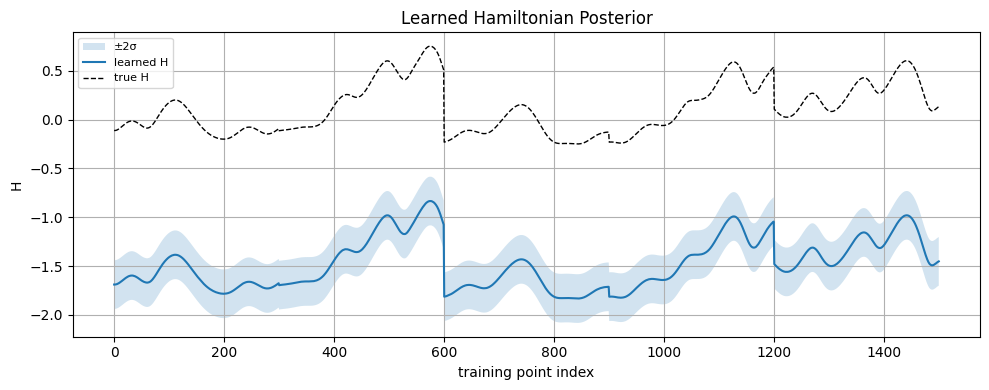

In [15]:
plot.pltHamiltonian(H_mean.numpy(), H_var.numpy(), H_true=H_true_all)

## Step 6: Callable $H^*$ Ensemble

Fit a GP interpolant to each posterior sample so $H^*$ can be evaluated and differentiated anywhere.

In [16]:
ensemble = [
    hamiltonian_approximator.HamiltonianApproximator(
        method='gp',
        lengthscale=posterior.lengthscale,
        signal_var=posterior.signal_var,
    ).fit(x_all_t, H_samples[i])
    for i in range(H_samples.shape[0])
]

## Step 7: Derivative Prediction

Verify that the learned model predicts $\dot{x} = (J(x) - R(x))\nabla H^*(x)$ correctly at training points before committing to full trajectory rollout. This is expected to hold up well even though long-horizon rollout will not -- pointwise gradient recovery does not require the system to be non-chaotic.

In [17]:
# EVALUATE LEARNED DYNAMICS: xdot = (J(x) - R(x)) grad_H*(x) + G(x)u
JR            = (phs.get_J(x_all_t) - phs.get_R(x_all_t)).detach().numpy()
G             = phs.get_G(x_all_t).detach().numpy()
grad_H_stack  = torch.stack([h.gradient(x_all_t) for h in ensemble])
grad_H_mean   = grad_H_stack.mean(0).detach().numpy()
grad_H_std    = grad_H_stack.std(0).detach().numpy()
xdot_pred     = np.einsum('nij,nj->ni', JR, grad_H_mean) + np.einsum('nij,nj->ni', G, u_all)
xdot_pred_std = np.einsum('nij,nj->ni', JR, grad_H_std)

### Plot

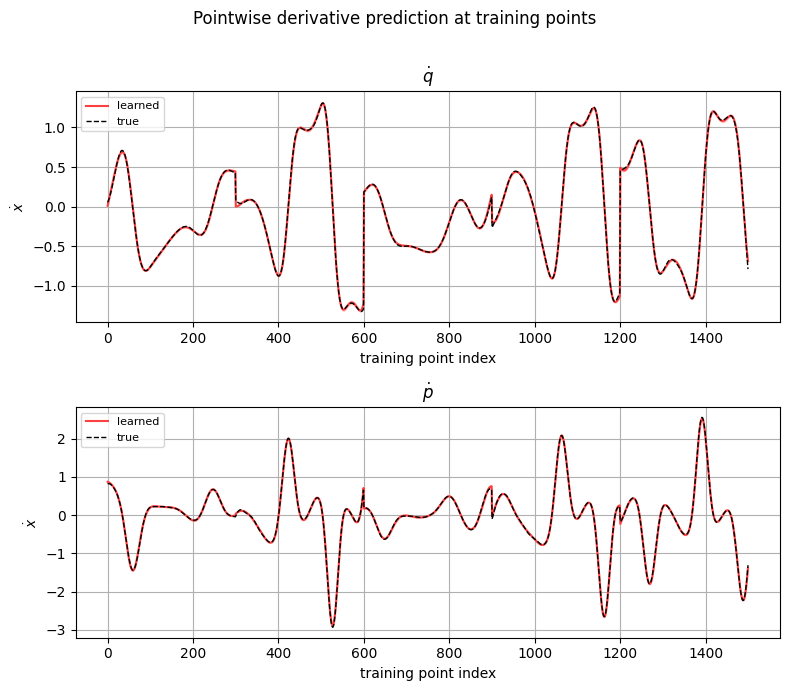

In [18]:
plot.pltXdot(
    xdot_pred, xdot_true,
    xdot_std=xdot_pred_std,
    state_lbls=[r'$\dot{q}$', r'$\dot{p}$'],
)

## Step 8: Trajectory Prediction


In [19]:
dt    = 0.005
t_sim = np.linspace(0.0, T_SIM, int(T_SIM / dt) + 1)

u_sim = torch.tensor(
    np.array([input_signal(t) for t in t_sim]),
    dtype=torch.float32,
).unsqueeze(1)

# True reference trajectories -- all initial conditions
traj_sims = [
    odeint(lambda state, t: dynamics(state, t, input_signal), x0, t_sim)
    for x0 in X0_TEST
]

# Simulate learned GP-PHS from all initial conditions
phsode = ode.PHSODE(phs, ensemble, NX, NU, method='euler')
with torch.no_grad():
    result = phsode.simulate(
        x0=torch.tensor(X0_TEST, dtype=torch.float32),
        t_span=(0.0, T_SIM),
        u=u_sim.expand(-1, len(X0_TEST), -1),
        dt=dt,
    )

t_gp = result['t_eval'].numpy()
mean = result['mean'].numpy()   # (T, N, nx)
std  = result['std'].numpy()    # (T, N, nx)

### Plot trajectory prediction

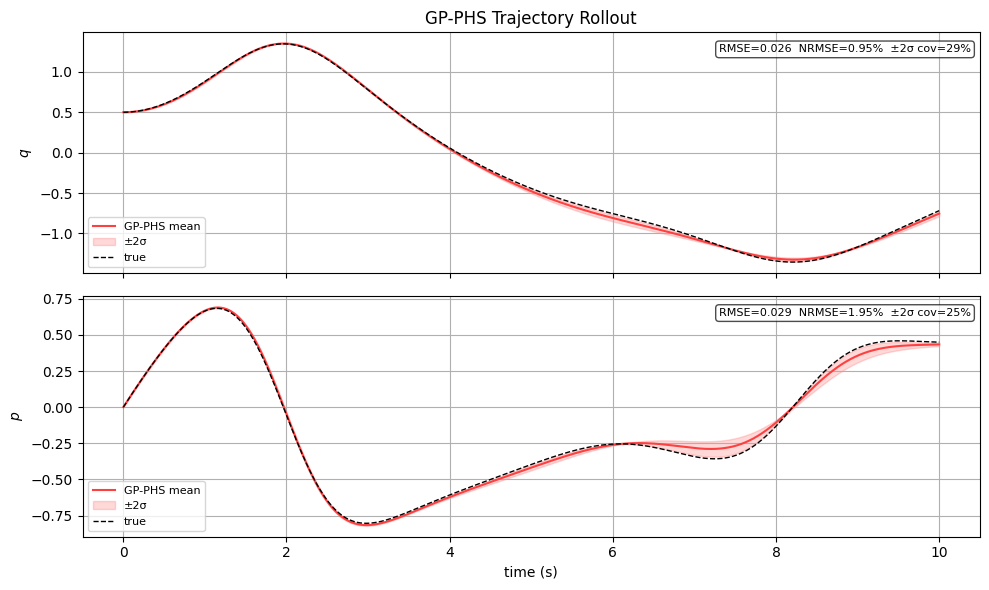

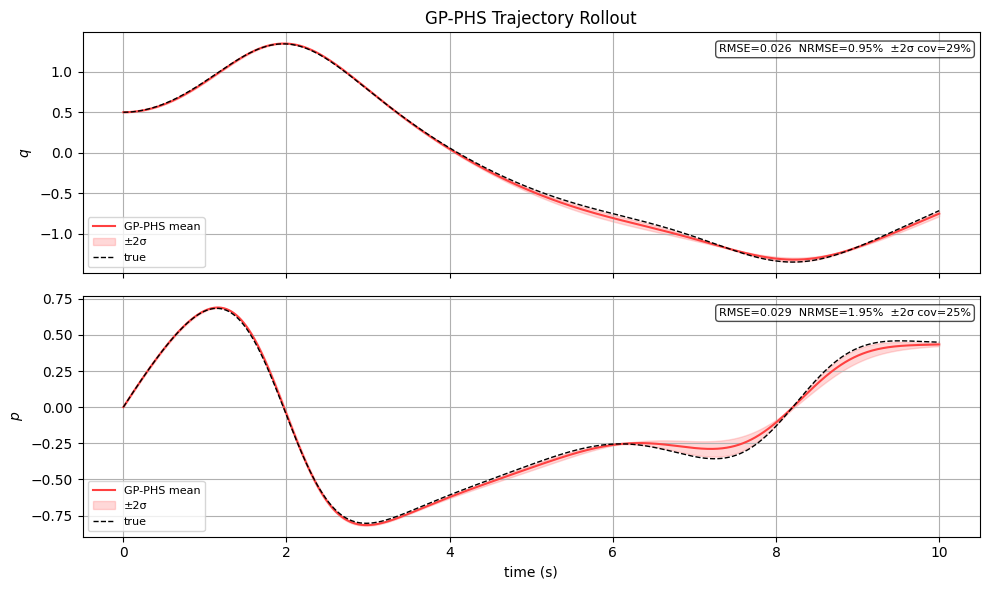

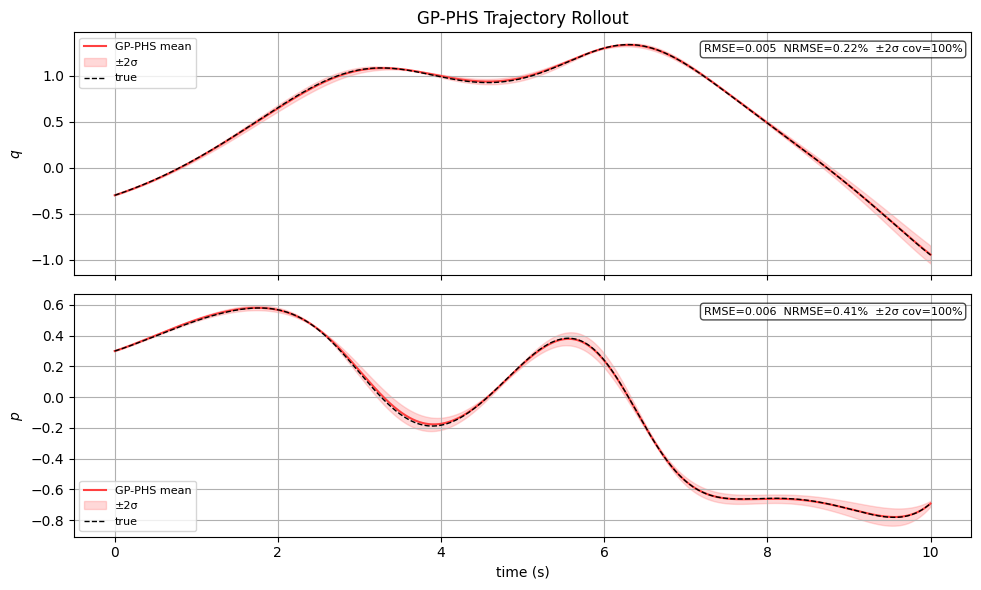

In [20]:
for i in range(len(X0_TEST)):
    plot.pltTrajectory(
        t_gp,
        mean[:, i, :],
        std=std[:, i, :],
        x_true=traj_sims[i],
        state_lbls=[r'$q$', r'$p$'],
        figname=f"traj_{i}",
    )